In [25]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np

In [26]:
base_url = "https://raw.githubusercontent.com/cdd369/CPSC5440/main/assignment_1/"

files = {
    0: base_url + "english.txt",
    1: base_url + "french.txt",
    2: base_url + "german.txt",
    #3: base_url + "spanish.txt"
}

data = []

for label, url in files.items():
    try:
        df_temp = pd.read_csv(
            url,
            header=None,
            names=["word"],
            encoding="utf-8"
        )
    except UnicodeDecodeError:
        df_temp = pd.read_csv(
            url,
            header=None,
            names=["word"],
            encoding="latin-1"
        )

    df_temp["label"] = label
    data.append(df_temp)

df = pd.concat(data, ignore_index=True)

print(df.head())

       word  label
0         a      0
1        aa      0
2       aaa      0
3    aachen      0
4  aardvark      0


In [27]:
df_5 = df[df["word"].str.len() == 5].copy()

print("Total 5-letter words:", len(df_5))
df_5.head()

Total 5-letter words: 21481


,word,label
9,aaron,0
16,ababa,0
18,abaca,0
20,abaci,0
21,aback,0


In [28]:
string_to_ord = []
for char in "rahul":
  string_to_ord.append(ord(char))
print(string_to_ord)

[114, 97, 104, 117, 108]


In [29]:
def word_to_ord(word):
    vector = []

    for char in word:
        vector.append(ord(char))

    return vector


# Apply encoding
X_ord = np.array(
    df_5["word"].apply(word_to_ord).tolist()
)

y_ord = df_5["label"].values

print("Original ord dataset shape:", X_ord.shape)
print(X_ord[:5])
print(y_ord[:5])

Original ord dataset shape: (21481, 5)
[[ 97  97 114 111 110]
 [ 97  98  97  98  97]
 [ 97  98  97  99  97]
 [ 97  98  97  99 105]
 [ 97  98  97  99 107]]
[0 0 0 0 0]


**Creating Tranining and Testing Data**

In [30]:
from sklearn.model_selection import train_test_split

# ----- Ord dataset -----
X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X_ord,
    y_ord,
    test_size=0.2,
    random_state=42
)

Impoting sklearn libraries for machine learning
1) KNN - K Nearest Neighbours
2) SVM - Support Vector Machine

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

**KNN - K Nearest Neighbours**

The K-Nearest Neighbors (KNN) model is a supervised machine learning algorithm used for classification and regression problems. It is a non-parametric and instance-based (lazy learning) method, meaning it does not build an explicit model during training; instead, it stores the training data and makes predictions using similarity.

HyperParametres

1. n_neighbours: KNeighborsClassifier(n_neighbors=5)
2. weight: uniform/distance, KNeighborsClassifier(weights='distance')
3. metric:   KNeighborsClassifier(metric='euclidean')
\begin{array}{|c|c|c|}
\hline
\textbf{Metric} & \textbf{Formula} & \textbf{Usage} \\
\hline
Euclidean & d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2} & Most common \\
\hline
Manhattan & d(x,y)=\sum_{i=1}^{n}|x_i-y_i| & Grid / city-block distance \\
\hline
Minkowski & d(x,y)=\left(\sum_{i=1}^{n}|x_i-y_i|^p\right)^{1/p} & Generalized distance (sklearn default) \\
\hline
Cosine & \cos(\theta)=\frac{x\cdot y}{\|x\|\|y\|} & Text / NLP problems \\
\hline
\end{array}

Minkowski Parameter 𝑝 Controls which distance metric is used.
| p value | Distance  |
| ------- | --------- |
| p = 1   | Manhattan |
| p = 2   | Euclidean |



4. algorithm: KNeighborsClassifier(algorithm='kd_tree')
| Algorithm | Description                       |
| --------- | --------------------------------- |
| auto      | Automatically selects best method |
| brute     | Computes distance with all points |
| kd_tree   | Efficient for low dimensions      |
| ball_tree | Efficient for moderate dimensions |

5. leaf_size: KNeighborsClassifier(leaf_size=30)
Used for tree-based search methods.

In [32]:
knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights='uniform', # uniform:best or distance
    metric='minkowski',
    p=1,
    algorithm='auto',
    leaf_size=10
)
knn_model.fit(X_train_ord, y_train_ord)
y_pred_knn = knn_model.predict(X_test_ord)
knn_acc = accuracy_score(y_test_ord, y_pred_knn)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.7337677449383291


###**Support Vector Machine (SVM)**
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression, originally developed by Vapnik and collaborators.


*   SVM finds the optimal hyperplane that separates data classes with maximum margin.
*   The data points closest to the hyperplane are called support vectors.

### SVM Hyperparameters

Support Vector Machine (SVM) has several important hyperparameters that control how the model learns and forms the decision boundary.

- **C (Regularization Parameter):** Controls the trade-off between maximizing the margin and minimizing classification error. A small C allows a wider margin with more misclassifications, while a large C tries to classify all training points correctly but may lead to overfitting.

- **Kernel:** Defines the type of decision boundary used to separate the data. Common kernels include `linear`, `poly` (polynomial), `rbf` (Radial Basis Function), and `sigmoid`. The RBF kernel is the most commonly used for nonlinear problems.

- **Gamma (γ):** Determines how far the influence of a single training example reaches. A small gamma creates a smoother decision boundary, while a large gamma makes the boundary more complex and sensitive to individual data points.

- **Degree:** Used only with the polynomial kernel. It controls the degree of the polynomial used to fit the data.

These hyperparameters must be tuned carefully to achieve the best model performance.




In [33]:
#svm_model = svm.SVC(kernel='rbf', C=10, gamma = 0.01) #, gamma='scale',random_state=42 #68.7
svm_model = svm.SVC(kernel='rbf', C=15, gamma=0.01) # 72.07
#svm_model = svm.SVC(kernel='linear', C=1)
svm_model.fit(X_train_ord, y_train_ord)
y_pred_svm = svm_model.predict(X_test_ord)
svm_acc = accuracy_score(y_test_ord, y_pred_svm)
print("SVM Accuracy:", svm_acc)



SVM Accuracy: 0.7381894344891785


###Multi-Layer Perceptron Neural Network
MLP NN (Multi-Layer Perceptron Neural Network) is a type of feed-forward artificial neural network widely used for classification and regression problems in machine learning.

Important Hyperparameters


*   hidden_layer_sizes – Defines the number of hidden layers and neurons in each layer (e.g., (100,), (128,64)).
*   activation – Activation function used in hidden layers ('logistic', 'relu', 'tanh', 'identity').
*   solver – Optimization algorithm used for training (adam, sgd, lbfgs).
*   alpha – L2 regularization parameter used to prevent overfitting.
*   learning_rate_init – Initial learning rate controlling weight updates.
*   max_iter – Maximum number of training iterations.
*  batch_size – Number of samples processed before updating weights.




















In [34]:
mlp_nn = MLPClassifier(
    hidden_layer_sizes=(100,50),
    # activation='relu',
    # solver='adam',
    # alpha=0.01,
    # learning_rate_init=0.01,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=15
)
# mlp_nn = MLPClassifier(
#     hidden_layer_sizes=(256,128),
#     max_iter=10000,
#     random_state=42,
#     early_stopping=True,
#     n_iter_no_change=25
# )

mlp_nn.fit(X_train_ord, y_train_ord)
y_pred_mlp = mlp_nn.predict(X_test_ord)
mlp_acc= accuracy_score(y_test_ord, y_pred_mlp)
print("MLP Accuracy:", mlp_acc)

MLP Accuracy: 0.7184081917616942


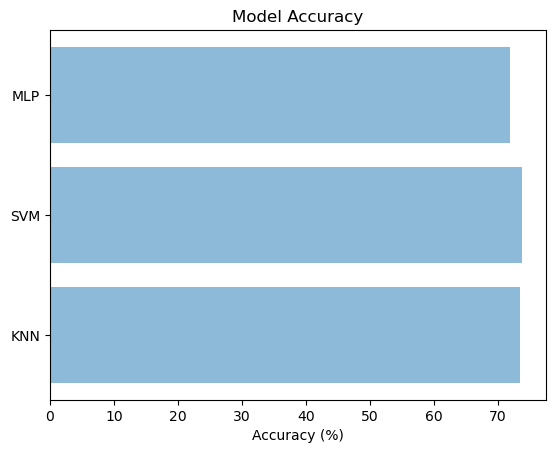

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Label text for each graph
labels = ("KNN", "SVM", "MLP")

# Numbers that you want the bars to represent
value = [knn_acc, svm_acc, mlp_acc]
value_per = [val*100 for val in value]
# Title of the plot
plt.title("Model Accuracy")

# Label for the x values of the bar graph
plt.xlabel("Accuracy (%)")

# Drawing the bar graph
y_pos = np.arange(len(labels))
plt.barh(y_pos, value_per, align="center", alpha=0.5)
plt.yticks(y_pos, labels)

# Display the graph
plt.show()